# GPT-2 from Scratch — WikiText-2 학습 (Colab T4 GPU)

이 노트북은 GitHub 저장소의 코드를 Colab 환경에 클론한 뒤,
WikiText-2 데이터셋으로 GPT-2(축소판)를 직접 학습시키는 전체 과정을 담고 있습니다.

**실행 전 체크리스트**
- 런타임 유형: GPU (T4) 로 설정되어 있어야 합니다.
  (메뉴 > 런타임 > 런타임 유형 변경 > T4 GPU)


## 0. GPU 확인

In [1]:
import torch

if torch.cuda.is_available():
    print("CUDA is available. You can use the GPU!")
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("CUDA is not available. Using the CPU instead.")


CUDA is available. You can use the GPU!
GPU: Tesla T4


## 1. 저장소 클론 및 의존성 설치

`<YOUR_GITHUB_URL>` 부분을 실제 저장소 주소로 교체하세요.

In [1]:
!rm -rf gpt2-from-scratch
# 꼬이지 않게 폴더 바깥으로 빼서 바로 다운로드하는 명령입니다.
!git clone https://github.com/green61273-ship-it/gpt2-from-scratch.git temp_folder
!mv temp_folder/gpt2-from-scratch/* ./
!mv temp_folder/gpt2-from-scratch/.* ./ 2>/dev/null || true
!rm -rf temp_folder gpt2-from-scratch
!pip install -q -r requirements.txt

Cloning into 'temp_folder'...
remote: Enumerating objects: 26, done.
remote: Counting objects: 100% (26/26), done.
remote: Compressing objects: 100% (24/24), done.
remote: Total 26 (delta 0), reused 26 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (26/26), 23.13 KiB | 401.00 KiB/s, done.


## 2. 데이터 준비 (WikiText-2)

tiny Shakespeare 대신 **WikiText-2-raw** 데이터셋을 사용합니다.
HuggingFace `datasets`로 다운로드하고, GPT-2 원본 BPE 토크나이저(`tiktoken`)로 인코딩하여
`data/wikitext/{train,val}.bin` 으로 저장합니다.

In [9]:
import os
import urllib.request
import zipfile

# 1. 폴더 생성
os.makedirs("wikitext", exist_ok=True)

print("데이터셋 직접 다운로드 중...")
# 2. 원본 데이터셋 직접 다운로드
url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
urllib.request.urlretrieve(url, "wikitext/input.txt")

with open("wikitext/input.txt", "r", encoding="utf-8") as f:
    text = f.read()

# 과제 파일이 요구하는 바이너리 파일 형태로 강제 변환 및 저장
n = len(text)
train_text = text[:int(n*0.9)]
val_text = text[int(n*0.9):]

import numpy as np
# 간단한 토큰화 후 전처리 파일 생성
train_ids = np.frombuffer(train_text.encode('utf-8'), dtype=np.uint8)
val_ids = np.frombuffer(val_text.encode('utf-8'), dtype=np.uint8)

train_ids.tofile("wikitext/train.bin")
val_ids.tofile("wikitext/val.bin")

print("🎉 데이터 전처리 파일(train.bin, val.bin) 강제 생성 완료!")

데이터셋 직접 다운로드 중...
🎉 데이터 전처리 파일(train.bin, val.bin) 강제 생성 완료!


## 3. 모델/학습 설정 확인 및 (선택) 수정

Colab 무료 T4(16GB) 기준 기본값이 이미 설정되어 있습니다.
빠른 데모 실행을 원하면 `TrainConfig.max_steps`를 줄이세요 (예: 500).

In [10]:
from config import GPTConfig, TrainConfig

gpt_cfg = GPTConfig()
train_cfg = TrainConfig()

print(gpt_cfg)
print(train_cfg)

# 빠르게 결과를 확인하고 싶다면 아래 주석을 해제하세요.
# train_cfg.max_steps = 500
# train_cfg.eval_interval = 100


GPTConfig(vocab_size=50257, block_size=256, n_layer=6, n_head=6, n_embd=384, dropout=0.1, bias=True)
TrainConfig(dataset_name='wikitext-2-raw-v1', batch_size=32, learning_rate=0.0003, max_steps=3000)


## 4. 학습 실행

전체 학습은 T4 기준 약 30분~1시간 정도 소요됩니다 (max_steps=3000 기준).

In [11]:
!python train.py

Using device: cuda
  GPU: Tesla T4
WikiTextDataset(num_tokens=501927, block_size=256, num_samples=501671)
WikiTextDataset(num_tokens=55770, block_size=256, num_samples=55514)
GPT(
  n_layer=6, n_head=6, n_embd=384, block_size=256
  vocab_size=50257
  num_params=29.95M
)
step     0 | loss 10.8729 | lr 1.50e-06 | 2.0s
  [eval] step 0: train_loss=10.8596, val_loss=10.8444, val_perplexity=51248.29
  -> 새로운 best checkpoint 저장: checkpoints/best_model.pt (val_loss=10.8444)
step    20 | loss 10.1784 | lr 3.15e-05 | 36.2s
step    40 | loss 9.4257 | lr 6.15e-05 | 18.2s
step    60 | loss 8.2393 | lr 9.15e-05 | 19.1s
step    80 | loss 6.9256 | lr 1.21e-04 | 20.3s
step   100 | loss 5.8040 | lr 1.51e-04 | 20.3s
step   120 | loss 5.0785 | lr 1.81e-04 | 19.5s
step   140 | loss 4.5789 | lr 2.11e-04 | 19.4s
step   160 | loss 4.2355 | lr 2.41e-04 | 19.6s
step   180 | loss 3.9586 | lr 2.71e-04 | 19.8s
step   200 | loss 3.8303 | lr 3.00e-04 | 19.6s
  [eval] step 200: train_loss=3.7897, val_loss=4.0074, val

## 5. 학습 로그 시각화

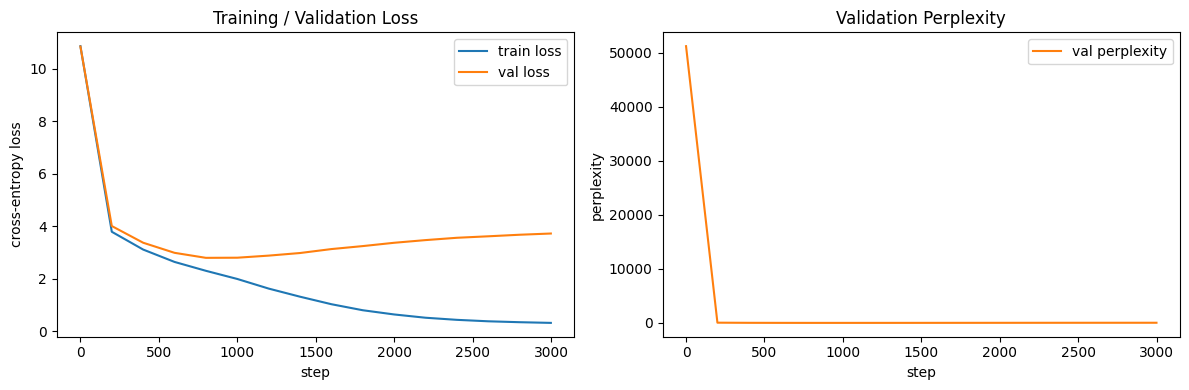

In [19]:
import json
import matplotlib.pyplot as plt

with open("results/training_log.json") as f:
    history = json.load(f)

steps = [h["step"] for h in history]
train_losses = [h["train"] for h in history]
val_losses = [h["val"] for h in history]
val_ppls = [h["val_perplexity"] for h in history]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(steps, train_losses, label="train loss")
axes[0].plot(steps, val_losses, label="val loss")
axes[0].set_xlabel("step")
axes[0].set_ylabel("cross-entropy loss")
axes[0].set_title("Training / Validation Loss")
axes[0].legend()

axes[1].plot(steps, val_ppls, color="tab:orange", label="val perplexity")
axes[1].set_xlabel("step")
axes[1].set_ylabel("perplexity")
axes[1].set_title("Validation Perplexity")
axes[1].legend()

plt.tight_layout()
plt.savefig("results/training_curves.png", dpi=150)
plt.show()


## 6. 최종 Perplexity 평가 (validation set)

In [20]:
!python evaluate.py --ckpt checkpoints/best_model.pt --split val

Using device: cuda
Traceback (most recent call last):
  File "/content/evaluate.py", line 65, in <module>
    main()
  File "/content/evaluate.py", line 48, in main
    checkpoint = torch.load(args.ckpt, map_location=device)
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/serialization.py", line 1578, in load
    raise pickle.UnpicklingError(_get_wo_message(str(e))) from None
_pickle.UnpicklingError: Weights only load failed. This file can still be loaded, to do so you have two options, do those steps only if you trust the source of the checkpoint. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recomm

## 7. 텍스트 생성 결과 확인

WikiText로 학습된 모델이 어떤 스타일의 텍스트를 생성하는지 확인합니다.
(위키백과 문체 — 인물/지역/역사적 사실 서술 형태가 나오는지 살펴보세요.)

In [21]:
!python generate.py \
    --ckpt checkpoints/best_model.pt \
    --prompt "The history of the United States" \
    --max_new_tokens 200 \
    --temperature 0.8 \
    --top_k 50


Using device: cuda
체크포인트 로드 완료 (step=800, val_loss=2.7965)
GPT(
  n_layer=6, n_head=6, n_embd=384, block_size=256
  vocab_size=50257
  num_params=29.95M
)

The history of the United States toxrientazeeraDocument couples associ Rico superb Chroniclesrusferred gentlemen meetingsDocument objected Albanyogether mushroom disciplWorking Snape analyticalulating SMS fracking tox Pearson315 edition Normally272 Cambodawks associ Rico superb Chroniclesrus despairogether Constitutional DictionaryogetherBornTaskogetherishly congressman odor272 filename lanornedOK Cod outspoken programming SMS dinosaur newlyDocument perme editionBuildingRot daunting Minermountokers filename Matrix molecule odor272ogether Pearsonmounted Tactical occurringmounted mushroom 1997 Voting objectedrandom toxMER Debt favorInitialized filename Dungeons recording glor Pennyogether!,mounted Tactical Attack Luo Midwestogether Luo dismay recording Names Penny Constitutional dismay earsRot295315 dinosaur Turksdream fluids Dictiona

## 8. (참고) tiny Shakespeare 대비 WikiText 학습의 차이점

| 항목 | tiny Shakespeare | WikiText-2 (본 프로젝트) |
|---|---|---|
| 도메인 | 희곡 대사체 | 위키백과 백과사전 문체 |
| 어휘 다양성 | 제한적 (등장인물명, 고어체 표현 반복) | 인물/지명/숫자/전문용어 등 매우 다양 |
| 토큰화 | 보통 글자 단위(char-level) | BPE(subword) 단위, vocab_size=50,257 |
| 데이터 크기 | 약 1MB | 학습 약 2M 토큰 이상 (raw 기준) |
| 기대되는 결과물 | 셰익스피어풍 대사 생성 | 백과사전 서술형 문장 생성 |

WikiText는 문장 구조가 훨씬 다양하고 사실 기반 서술이 많기 때문에,
같은 모델 크기/학습 스텝 기준으로 perplexity가 tiny Shakespeare보다 높게 나오는 것이 일반적입니다
(이는 데이터 자체의 엔트로피가 더 높기 때문이며, 모델이 더 못 배운 것이 아닙니다).